#1 Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#2 Upload cleaned data

In [2]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_customer_transactions.csv to cleaned_customer_transactions.csv


#3 Load the dataset

In [3]:
df = pd.read_csv("cleaned_customer_transactions.csv")
display(df.head())

,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,DiscountPercent,Revenue,ProductCategory,Country,Region,AcquisitionChannel,SubscriptionPlan,OrderStatus,PaymentMethod,TransactionMonth,CohortMonth,CohortIndex
0,INV100002,C00001,2026-01-05,3,167.05,15,425.9775,Education,India,East,Organic Search,Basic,Completed,Net Banking,2026-01-01,2026-01-01,1
1,INV100003,C00001,2026-01-01,4,477.13,15,1622.2420,Software,India,East,Organic Search,Basic,Completed,Debit Card,2026-01-01,2026-01-01,1
2,INV100004,C00002,2026-02-06,1,562.38,5,534.2610,Books,United Kingdom,North,Referral,Basic,Completed,UPI,2026-02-01,2026-02-01,1
3,INV100005,C00002,2026-02-08,2,558.93,0,1117.8600,Books,United Kingdom,North,Referral,Basic,Completed,Debit Card,2026-02-01,2026-02-01,1
4,INV100006,C00002,2026-03-06,2,177.19,0,354.3800,Fashion,United Kingdom,North,Referral,Basic,Completed,UPI,2026-03-01,2026-02-01,2


#4 Convert date columns

In [4]:
date_columns = ["InvoiceDate", "TransactionMonth", "CohortMonth"]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[date_columns].dtypes)

InvoiceDate         datetime64[ns]
TransactionMonth    datetime64[ns]
CohortMonth         datetime64[ns]
dtype: object


#5 Validate required columns

In [5]:
required_columns = [
    "CustomerID",
    "InvoiceDate",
    "TransactionMonth",
    "CohortMonth",
    "CohortIndex"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Unique customers:", df["CustomerID"].nunique())
print(
    "Cohort range:",
    df["CohortMonth"].min(),
    "to",
    df["CohortMonth"].max()
)
print(
    "Maximum CohortIndex:",
    df["CohortIndex"].max()
)

Unique customers: 1157
Cohort range: 2025-01-01 00:00:00 to 2026-06-01 00:00:00
Maximum CohortIndex: 13


#6 Cohort distribution

In [6]:
cohort_distribution = (
    df.groupby("CohortMonth")["CustomerID"]
    .nunique()
    .reset_index(name="Customers")
    .sort_values("CohortMonth")
)

display(cohort_distribution)

,CohortMonth,Customers
0,2025-01-01,39
1,2025-02-01,69
2,2025-03-01,86
3,2025-04-01,74
4,2025-05-01,88
5,2025-06-01,80
6,2025-07-01,66
7,2025-08-01,65
8,2025-09-01,74
9,2025-10-01,75


#7 Build cohort customer counts

In [7]:
cohort_counts = (
    df.groupby(
        ["CohortMonth", "CohortIndex"]
    )["CustomerID"]
    .nunique()
    .reset_index(name="Customers")
)

display(cohort_counts.head(20))

,CohortMonth,CohortIndex,Customers
0,2025-01-01,1,39
1,2025-01-01,2,19
2,2025-01-01,3,13
3,2025-01-01,4,11
4,2025-01-01,5,4
5,2025-01-01,6,3
6,2025-01-01,7,1
7,2025-01-01,8,2
8,2025-01-01,9,1
9,2025-01-01,10,1


#8 Create cohort count matrix

In [8]:
cohort_count_matrix = cohort_counts.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customers"
)

cohort_count_matrix = cohort_count_matrix.sort_index()

display(cohort_count_matrix)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2025-01-01,39.0,19.0,13.0,11.0,4.0,3.0,1.0,2.0,1.0,1.0,1.0,NaN,NaN
2025-02-01,69.0,37.0,23.0,15.0,11.0,11.0,4.0,4.0,4.0,1.0,3.0,2.0,1.0
2025-03-01,86.0,46.0,32.0,17.0,9.0,6.0,5.0,3.0,2.0,1.0,NaN,1.0,NaN
2025-04-01,74.0,36.0,21.0,21.0,13.0,4.0,7.0,3.0,1.0,NaN,NaN,NaN,NaN
2025-05-01,88.0,39.0,28.0,18.0,9.0,9.0,4.0,4.0,5.0,2.0,1.0,NaN,NaN
2025-06-01,80.0,35.0,30.0,15.0,6.0,3.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN
2025-07-01,66.0,35.0,25.0,15.0,10.0,9.0,7.0,3.0,3.0,2.0,NaN,1.0,NaN
2025-08-01,65.0,34.0,26.0,15.0,9.0,2.0,3.0,2.0,1.0,2.0,NaN,NaN,NaN
2025-09-01,74.0,36.0,26.0,16.0,12.0,6.0,5.0,3.0,1.0,2.0,NaN,NaN,NaN


#9 Calculate retention %

In [9]:
cohort_sizes = cohort_count_matrix[1]

retention_matrix = cohort_count_matrix.divide(
    cohort_sizes,
    axis=0
) * 100

retention_matrix = retention_matrix.round(2)

display(retention_matrix)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2025-01-01,100.0,48.72,33.33,28.21,10.26,7.69,2.56,5.13,2.56,2.56,2.56,NaN,NaN
2025-02-01,100.0,53.62,33.33,21.74,15.94,15.94,5.80,5.80,5.80,1.45,4.35,2.90,1.45
2025-03-01,100.0,53.49,37.21,19.77,10.47,6.98,5.81,3.49,2.33,1.16,NaN,1.16,NaN
2025-04-01,100.0,48.65,28.38,28.38,17.57,5.41,9.46,4.05,1.35,NaN,NaN,NaN,NaN
2025-05-01,100.0,44.32,31.82,20.45,10.23,10.23,4.55,4.55,5.68,2.27,1.14,NaN,NaN
2025-06-01,100.0,43.75,37.50,18.75,7.50,3.75,2.50,1.25,1.25,NaN,NaN,NaN,NaN
2025-07-01,100.0,53.03,37.88,22.73,15.15,13.64,10.61,4.55,4.55,3.03,NaN,1.52,NaN
2025-08-01,100.0,52.31,40.00,23.08,13.85,3.08,4.62,3.08,1.54,3.08,NaN,NaN,NaN
2025-09-01,100.0,48.65,35.14,21.62,16.22,8.11,6.76,4.05,1.35,2.70,NaN,NaN,NaN


#10 Validate Month 1

In [10]:
month_1_values = retention_matrix[1].dropna()

print(
    "Month 1 minimum retention:",
    month_1_values.min()
)

print(
    "Month 1 maximum retention:",
    month_1_values.max()
)

assert np.allclose(
    month_1_values.values,
    100.0
), "Month 1 retention should be 100%."

print(
    "Validation passed: Month 1 retention = 100%"
)

Month 1 minimum retention: 100.0
Month 1 maximum retention: 100.0
Validation passed: Month 1 retention = 100%


#11 Prepare the matrix for Power BI

In [11]:
retention_powerbi = retention_matrix.copy()

retention_powerbi.columns = [
    f"Month_{int(col)}"
    for col in retention_powerbi.columns
]

retention_powerbi = retention_powerbi.reset_index()

display(retention_powerbi.head())

,CohortMonth,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,Month_13
0,2025-01-01,100.0,48.72,33.33,28.21,10.26,7.69,2.56,5.13,2.56,2.56,2.56,NaN,NaN
1,2025-02-01,100.0,53.62,33.33,21.74,15.94,15.94,5.80,5.80,5.80,1.45,4.35,2.90,1.45
2,2025-03-01,100.0,53.49,37.21,19.77,10.47,6.98,5.81,3.49,2.33,1.16,NaN,1.16,NaN
3,2025-04-01,100.0,48.65,28.38,28.38,17.57,5.41,9.46,4.05,1.35,NaN,NaN,NaN,NaN
4,2025-05-01,100.0,44.32,31.82,20.45,10.23,10.23,4.55,4.55,5.68,2.27,1.14,NaN,NaN


#12 Create long-format retention data

In [12]:
retention_long = (
    retention_matrix
    .reset_index()
    .melt(
        id_vars="CohortMonth",
        var_name="MonthNumber",
        value_name="RetentionRate"
    )
)

retention_long["MonthNumber"] = (
    retention_long["MonthNumber"].astype(int)
)

retention_long = retention_long.sort_values(
    ["CohortMonth", "MonthNumber"]
).reset_index(drop=True)

display(retention_long.head(20))

,CohortMonth,MonthNumber,RetentionRate
0,2025-01-01,1,100.00
1,2025-01-01,2,48.72
2,2025-01-01,3,33.33
3,2025-01-01,4,28.21
4,2025-01-01,5,10.26
5,2025-01-01,6,7.69
6,2025-01-01,7,2.56
7,2025-01-01,8,5.13
8,2025-01-01,9,2.56
9,2025-01-01,10,2.56


#13 Calculate average retention curve

In [13]:
average_retention = (
    retention_long
    .groupby(
        "MonthNumber",
        as_index=False
    )["RetentionRate"]
    .mean()
)

average_retention["RetentionRate"] = (
    average_retention["RetentionRate"]
    .round(2)
)

display(average_retention)

,MonthNumber,RetentionRate
0,1,100.00
1,2,50.85
2,3,35.57
3,4,23.30
4,5,13.36
5,6,8.46
6,7,5.88
7,8,4.52
8,9,3.17
9,10,2.32


#14 Create retention curve chart

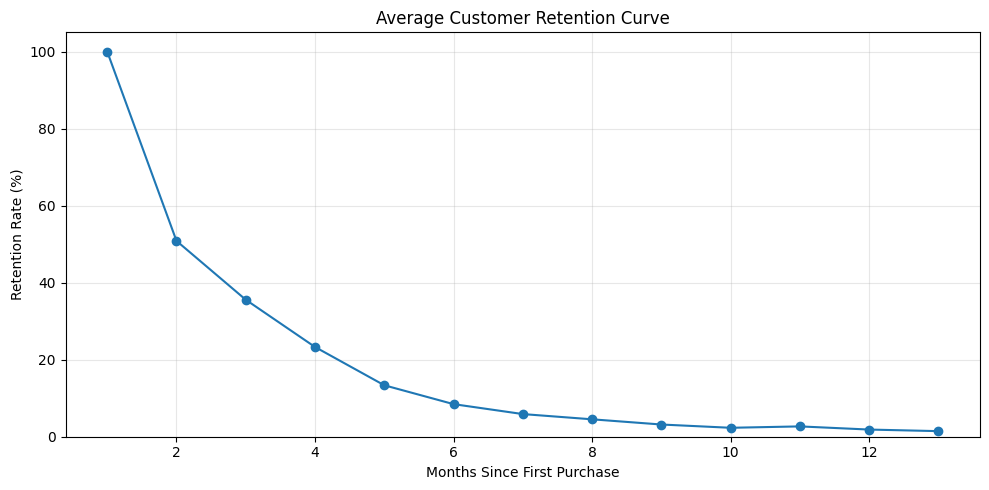

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    average_retention["MonthNumber"],
    average_retention["RetentionRate"],
    marker="o"
)

plt.title(
    "Average Customer Retention Curve"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Retention Rate (%)"
)

plt.ylim(0, 105)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "retention_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#15 Create retention heatmap

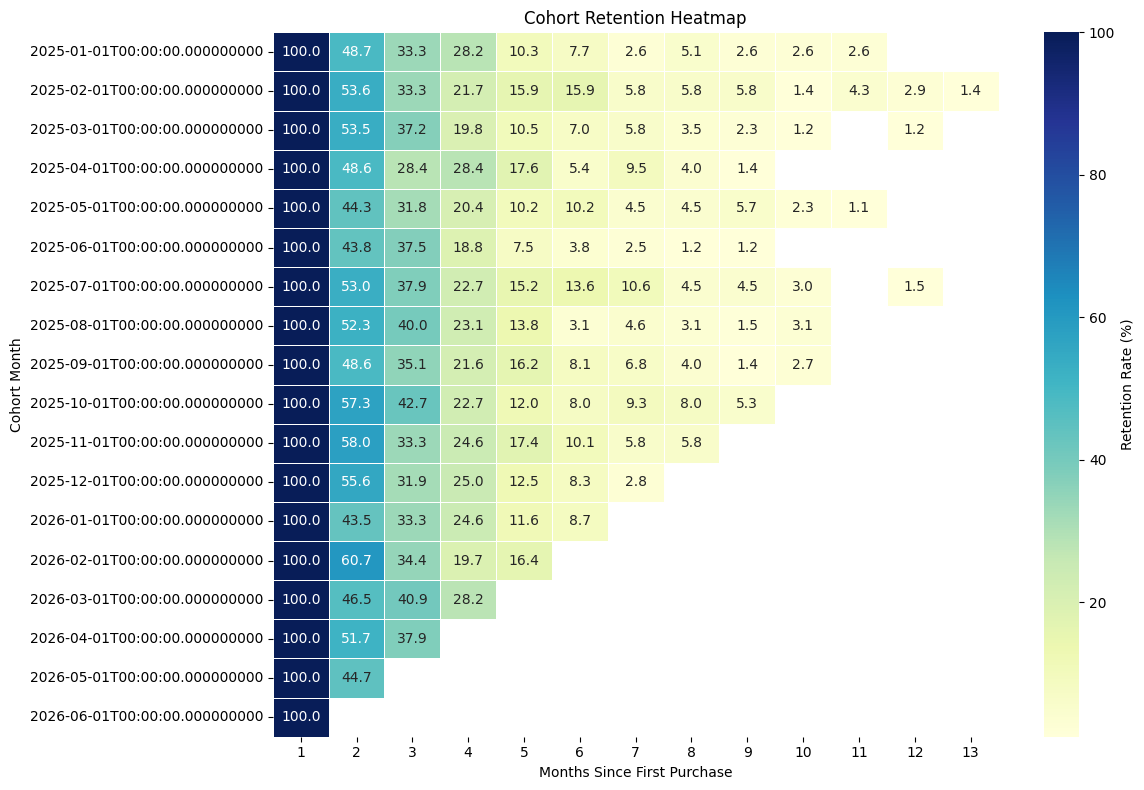

In [21]:
import seaborn as sns

heatmap_data = retention_matrix.copy()

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title("Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.savefig(
    "retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#16 Calculate cohort KPIs

In [16]:
total_customers = df["CustomerID"].nunique()

customer_order_counts = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

repeat_customers = int(
    (customer_order_counts > 1).sum()
)

one_time_customers = int(
    (customer_order_counts == 1).sum()
)

repeat_customer_rate = (
    repeat_customers / total_customers * 100
    if total_customers > 0
    else 0
)

#17 Export Power BI files

In [19]:
cohort_count_matrix.to_csv(
    "cohort_customer_counts.csv",
    index=False
)

retention_powerbi.to_csv(
    "cohort_retention_matrix.csv",
    index=False
)

retention_long.to_csv(
    "cohort_retention_long.csv",
    index=False
)

average_retention.to_csv(
    "average_retention_curve.csv",
    index=False
)

cohort_kpis_df = pd.DataFrame({
    "KPI": [
        "total_customers",
        "repeat_customers",
        "one_time_customers",
        "repeat_customer_rate"
    ],
    "Value": [
        total_customers,
        repeat_customers,
        one_time_customers,
        repeat_customer_rate
    ]
})

cohort_kpis_df.to_csv(
    "cohort_kpis.csv",
    index=False
)

#18 Download outputs

In [22]:
from google.colab import files

files.download(
    "cohort_retention_matrix.csv"
)

files.download(
    "cohort_retention_long.csv"
)

files.download(
    "average_retention_curve.csv"
)

files.download(
    "cohort_kpis.csv"
)

files.download(
    "retention_curve.png"
)

files.download(
    "retention_heatmap.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>